In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rakesrishtik/dolly15k-partial-trained/unsloth_compiled_cache/UnslothCPOTrainer.py
/kaggle/input/datasets/rakesrishtik/dolly15k-partial-trained/unsloth_compiled_cache/UnslothXPOTrainer.py
/kaggle/input/datasets/rakesrishtik/dolly15k-partial-trained/unsloth_compiled_cache/UnslothAlignPropTrainer.py
/kaggle/input/datasets/rakesrishtik/dolly15k-partial-trained/unsloth_compiled_cache/UnslothKTOTrainer.py
/kaggle/input/datasets/rakesrishtik/dolly15k-partial-trained/unsloth_compiled_cache/UnslothOnlineDPOTrainer.py
/kaggle/input/datasets/rakesrishtik/dolly15k-partial-trained/unsloth_compiled_cache/UnslothPPOTrainer.py
/kaggle/input/datasets/rakesrishtik/dolly15k-partial-trained/unsloth_compiled_cache/UnslothGKDTrainer.py
/kaggle/input/datasets/rakesrishtik/dolly15k-partial-trained/unsloth_compiled_cache/UnslothRLOOTrainer.py
/kaggle/input/datasets/rakesrishtik/dolly15k-partial-trained/unsloth_compiled_cache/UnslothSFTTrainer.py
/kaggle/input/datasets/rakesrishtik/dolly1

In [2]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
# Pin these two exactly — this is the version combo known to work cleanly with
# Unsloth's gradient checkpointing on T4/P100 (avoids the bf16/GradScaler bug
# and the newer-trl API changes like tokenizer->processing_class).
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install wandb


In [3]:
from datasets import load_dataset

train=load_dataset("databricks/databricks-dolly-15k",split="train")

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

In [4]:
train[0]

{'instruction': 'When did Virgin Australia start operating?',
 'context': "Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.",
 'response': 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.',
 'category': 'closed_qa'}

In [5]:
from unsloth import FastLanguageModel

model,tokenizer=FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen3-0.6B",
    load_in_4bit=True,
    max_seq_length=2048,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.7.1: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [6]:
def change_to_dolly(examples):
    instruction=examples["instruction"]
    context=examples["context"]
    response=examples["response"]
    conversations=[
        {"role":"user","content":(f"Given the instruction:{instruction}\n and the context:{context}\n , give the correct response")},
        {"role":"assistant","content":response},
    ]
    text=tokenizer.apply_chat_template(conversations,tokenize=False,add_generation_prompt=False)
    return {"text":text,}


In [7]:
type(train)

datasets.arrow_dataset.Dataset

In [8]:

train_updated=train.shuffle(seed=42).select(range(14500))

In [9]:
test=train.shuffle(seed=42).select(range(14500,15000))

In [10]:
len(test),len(train_updated)

(500, 14500)

In [11]:
train_updated=train_updated.map(change_to_dolly)

Map:   0%|          | 0/14500 [00:00<?, ? examples/s]

In [12]:
type(train_updated)

datasets.arrow_dataset.Dataset

In [13]:
train_updated[0]

{'instruction': 'Who were the children of the legendary Garth Greenhand, the High King of the First Men in the series A Song of Ice and Fire?',
 'context': '',
 'response': 'Garth the Gardener, John the Oak, Gilbert of the Vines, Brandon of the Bloody Blade, Foss the Archer, Owen Oakenshield, Harlon the Hunter, Herndon of the Horn, Bors the Breaker, Florys the Fox, Maris the Maid, Rose of the Red Lake, Ellyn Ever Sweet, Rowan Gold-Tree',
 'category': 'open_qa',
 'text': '<|im_start|>user\nGiven the instruction:Who were the children of the legendary Garth Greenhand, the High King of the First Men in the series A Song of Ice and Fire?\n and the context:\n , give the correct response<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nGarth the Gardener, John the Oak, Gilbert of the Vines, Brandon of the Bloody Blade, Foss the Archer, Owen Oakenshield, Harlon the Hunter, Herndon of the Horn, Bors the Breaker, Florys the Fox, Maris the Maid, Rose of the Red Lake, Ellyn Ever Sweet, Row

In [14]:
test_updated=test.map(change_to_dolly)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
import wandb
wandb.login(key=key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rakesrishtik (rakesrishtik-iiitkottayam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
from trl import SFTTrainer, SFTConfig
import torch
import matplotlib.pyplot as plt

def train_adapter(dataset,test_dataset,output_dir,key):
    
    wandb.init(
        project="qwen3-trained-on-dolly-15k",
        id="2jik99sn",       # the run ID from your original run (from the run URL)
        resume="must",
        name=output_dir,
        config={
            "model": "qwen3-0.6B",
            "r": 16,
            "lora_alpha": 32,
            "max_steps": 5625,
            "learning_rate": 2e-4,
            "batch_size": 2,
            "gradient_accumulation_steps": 4,
            "warmup_steps": 5,
            "weight_decay": 0.001,
            "lr_scheduler": "linear",
            "max_seq_length": 2048,
        }
    )
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name="unsloth/Qwen3-0.6B",
        max_seq_length=2048,
        load_in_4bit=True,
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_alpha=32,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=3407,
        use_rslora=False,
        loftq_config=None,
    )
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=dataset,
        eval_dataset=test_dataset,
        args=SFTConfig(
            dataset_text_field="text",
            per_device_train_batch_size=2,
            gradient_accumulation_steps=8,      # smoother effective batch (16)
            warmup_ratio=0.03,                  # ~170 steps warmup instead of 5
            max_steps=5625,
            learning_rate=2e-5,
            lr_scheduler_type="cosine",         # gentler than linear after warmup
            fp16=True,                          # explicit, since T4 has no bf16
            optim="adamw_8bit",
            weight_decay=0.001,
            seed=3407,
            report_to="wandb",
            output_dir=output_dir,
            save_strategy="steps",
            save_steps=125,
            save_total_limit=5,
            eval_strategy="steps",
            eval_steps=20,
            max_grad_norm=1.0,
            max_seq_length=2048,                # match model load config
            logging_nan_inf_filter=True,        # let Trainer smooth transient spikes while you stabilize the rest
        )
    )
    from unsloth.chat_templates import train_on_responses_only

    trainer = train_on_responses_only(
        trainer,
        instruction_part="<|im_start|>user\n",
        response_part="<|im_start|>assistant\n",
    )
    trainer.train(resume_from_checkpoint="/kaggle/input/datasets/rakesrishtik/dolly15k-partial-trained/qwen3-trained-on-dolly-15k/checkpoint-1500")
    log_history=trainer.state.log_history
    steps      = [e["step"] for e in log_history if "loss" in e and "eval_loss" not in e]
    losses     = [e["loss"] for e in log_history if "loss" in e and "eval_loss" not in e]
    grad_steps = [e["step"] for e in log_history if "grad_norm" in e]
    grad_norms = [e["grad_norm"] for e in log_history if "grad_norm" in e]
    eval_steps  = [e["step"] for e in log_history if "eval_loss" in e]
    eval_losses = [e["eval_loss"] for e in log_history if "eval_loss" in e]

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(steps, losses, color="steelblue", label="Train Loss")
    if eval_losses:
        ax1.plot(eval_steps, eval_losses, color="red",
                 linestyle="--", marker="o", label="Eval Loss")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"Training Curves — {output_dir}")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(grad_steps, grad_norms, color="darkorange")
    ax2.set_ylabel("Gradient Norm")
    ax2.set_xlabel("Steps")
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f"{output_dir}_curves.png")
    wandb.log({"training_curves": wandb.Image(f"{output_dir}_curves.png")})
    plt.show()
    wandb.finish()

    model.save_pretrained(output_dir)
    model.push_to_hub(f"Srishtik/{output_dir}",token=key)
    tokenizer.push_to_hub(f"Srishtik/{output_dir}",token=key)

wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260707_171508-2jik99sn
wandb: Run `wandb offline` to turn off syncing.
wandb: Resuming run qwen3-trained-on-dolly-15k
wandb: ⭐️ View project at https://wandb.ai/rakesrishtik-iiitkottayam/qwen3-trained-on-dolly-15k
wandb: 🚀 View run at https://wandb.ai/rakesrishtik-iiitkottayam/qwen3-trained-on-dolly-15k/runs/2jik99sn
wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


==((====))==  Unsloth 2026.7.1: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2026.7.1 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/14500 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/500 [00:00<?, ? examples/s]

...

Unsloth: Removed 1 out of 500 samples from eval_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 14,476 | Num Epochs = 7 | Total steps = 5,625
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 10,092,544 of 606,142,464 (1.67% trained)


Step,Training Loss,Validation Loss
1520,2.424500,1.859940
1540,1.598600,1.861086
1560,2.329400,1.861577
1580,1.507400,1.860126
1600,1.890200,1.861062
1620,2.132600,1.860805
1640,2.444800,1.862078
1660,2.611100,1.861808
1680,1.916600,1.861095
1700,1.852500,1.861121


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


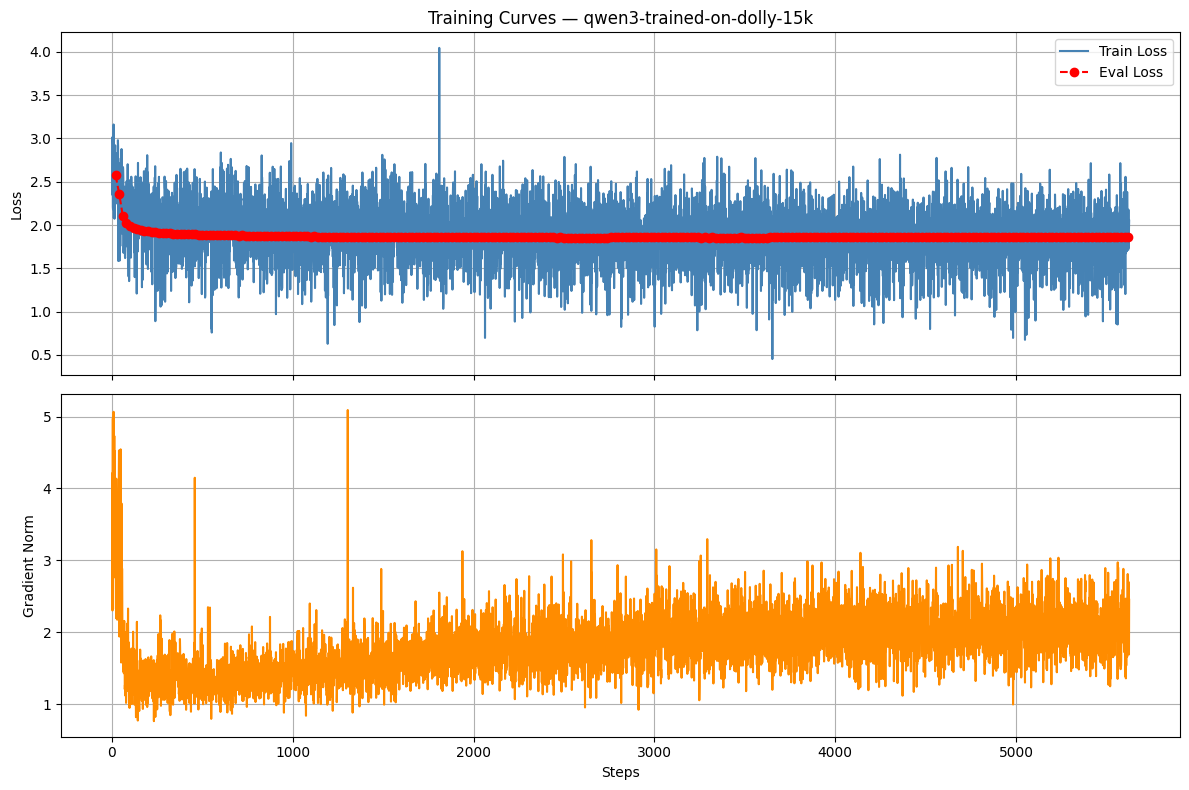

wandb: updating run metadata
wandb: uploading history steps 5987-5991, summary
wandb: 
wandb: Run history:
wandb:               eval/loss ▆█▆▇▅▇▅▆▇▄▃▃▃▂▃▃▁▂▂▁▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▄▅▅▅▅
wandb:            eval/runtime █▃▃▄▃▄▁▃▂▅▃▃▃▃▂▃▁▃▃▃▂▆▃▂▃▅▃▄▃▄▂▃▃▃▄▂▃▃▃▂
wandb: eval/samples_per_second ▁▇▆▆▇▆▇███▇█▇█▇▇▇▇▇▇▇▇▇▇▅▇█▇▆▆▆▇▇▇▇████▇
wandb:   eval/steps_per_second ▁▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▆▇▇▇▇▇▇▇▇▇▇▇▆▇█
wandb:             train/epoch ▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█████
wandb:       train/global_step ▁▁▁▁▁▂▂▂▂▂▂▂▂▂▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
wandb:         train/grad_norm ▂▂▂▂▃▄▂▄▆▇▁▅▁▄▇▆▄▅▆▂▆▃▄▄▆▆▂█▅▃▅▆▃▇▅▇▅▄▁▃
wandb:     train/learning_rate ████▇▇▇▆▆▆▅▅▅▅▅▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁
wandb:              train/loss ▃▄▅▁▇▆▄▄▅▂▄▆▅█▄▆▂▄▇▅▇▅▅▅▆▆▂▇▅▄▂▆▅▅▆▅▆▂▆▄
wandb: 
wandb: Run summary:
wandb:               eval/loss 1.85852
wandb:            eval/runtime 26.9183
wandb: eval/samples_per_second 18.538
wandb:   eval/steps_per_second 4.644
wandb:              total_flos 7.051593449472e+16
wandb:        

README.md:   0%|          | 0.00/560 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/Srishtik/qwen3-trained-on-dolly-15k


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

In [17]:
train_adapter(train_updated,test_updated,"qwen3-trained-on-dolly-15k")